In [1]:
import xarray as xr
import numpy as np
import cftime
import cmocean as cm
import matplotlib.pyplot as plt
import regionmask
from xmip.regionmask import merged_mask
import cartopy.crs as ccrs
import os
import pandas as pd
from pandas import Timestamp
# from xarrayutils.plotting import linear_piecewise_scale
from xarrayutils.plotting import box_plot
%matplotlib inline

In [2]:
# Repeats
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Dynamic_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Dynamic_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 30 warming 
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce15x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Dynamic_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp 15 warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnlyNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce7_5x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth' # temp 7.5 warming

# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfNoJump3xcc1975Epochs70Epoch55Years100_10repeat_newforce30x_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Dynamic_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' #all warming
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Dynamic_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming

In [3]:
# 2002 No warming
# Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-25_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_2002_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
# label_temp = '2002-2012 - Slow'
# Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-25_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_2002_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming
# label_all = '2002-2012 - Slow+Fast'

# No warming
Pred_path_temp = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHfTempOnly1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # temp no warming
label_temp = 'Thermo'
Pred_path_all = '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3DhfdsanomsNetZeroHf1975Epochs70Epoch55Years100_10repeat_36_6k_Train_global_3D_Test_global_3D_all_N_train_0_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_0_rand_seed_1.zarr' # all no warming
label_all = 'Thermo+Dynamic'

warming = False
if warming:
    suffix = "_warming"
else:
    suffix = ""

In [4]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})


    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out

levels = 19
emulation_stability=True
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data 
if smooth:
    window = 10
    with ProgressBar():
        ds_input['uo'] = ds_input.uo.rolling(time=window, min_periods=1, center=False).mean().compute()
        ds_input['vo'] = ds_input.vo.rolling(time=window, min_periods=1, center=False).mean().compute()


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 10
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31"))
    new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth['time'] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7303))

else:
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = ['uo', 'vo', 'thetao', 'so', 'zos'] #['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ['thetao', 'so', 'zos']
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_temp.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

output_path = "../outputs/" + label_temp+"_"+label_all
print("Using Output Folder : ", output_path)
if not os.path.isdir(os.path.join(output_path)):
    os.makedirs(os.path.join(output_path))


ds_prediction_raw_all = xr.open_zarr(Pred_path_all).isel(time=slice(None,7200))
ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp).isel(time=slice(None,7200))
ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw_temp.time.size))

# ds_prediction_all = post_processor(
#     ds_prediction_raw_all, ds_groundtruth, ls_all
# )
ds_prediction_all = post_processor(
    ds_prediction_raw_all, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_temp.time.size)), ls_all
)

ds_prediction_temp = post_processor(
    ds_prediction_raw_temp, ds_groundtruth.isel(time = slice(0,ds_prediction_raw_temp.time.size)), ls_temp
)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)

Using Output Folder :  ../outputs/Thermo_Thermo+Dynamic


In [5]:
ds_prediction_temp = ds_prediction_temp.transpose('time','lev',...)
ds_prediction_all = ds_prediction_all.transpose('time','lev',...)

In [6]:
ds_prediction_all['y']  = ds_prediction_all.y.assign_attrs(long_name='latitude', units = r"${^o}$")
ds_prediction_all['x']  = ds_prediction_all.x.assign_attrs(long_name='longitude', units = r"${^o}$")
ds_prediction_all['thetao'] = ds_prediction_all['thetao'].assign_attrs(long_name = r'$\theta_O$', units = r"${^oC}$")

ds_prediction_temp['y']  = ds_prediction_temp.y.assign_attrs(long_name='latitude', units = r"${^o}$")
ds_prediction_temp['x']  = ds_prediction_temp.x.assign_attrs(long_name='longitude')
ds_prediction_temp['thetao'] = ds_prediction_temp['thetao'].assign_attrs(long_name = r'$\theta_O$', units = r"${^oC}$")

In [7]:
# color_1 = '#DE3A41'
# color_2 = '#277DC7'

# clist = ["#D7191C","#DE7400","#00BD8E","#3300EA"]
color_2 = '#ff807a'
color_1 = '#1e8685'

In [8]:
# ds_prediction_temp = ds_prediction_temp.rolling(time=6, center=True).mean().dropna("time")
# ds_prediction_all = ds_prediction_all.rolling(time=6, center=True).mean().dropna("time")

### OHC

In [34]:
# Days_to_Eq = 0

# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(figsize=(10, 3))  # Adjusted height

# OHC_pred = (ds_prediction_all['thetao'][Days_to_Eq:]*c_p*rho_0).weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# OHC_pred = OHC_pred.rename('Ocean Heat Content')
# OHC_pred = OHC_pred.assign_attrs(units = 'J')

# OHC_pred.plot(ax = ax, label = label_all, c = color_1)

# OHC_pred_temp = (ds_prediction_temp['thetao'][Days_to_Eq:]*c_p*rho_0).weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
# OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J')

# OHC_pred_temp.plot(ax = ax, label = label_temp, c = color_2)

# ax.legend()
# ax.set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[:].size), OHC_pred[:], 1)
# ax.plot(OHC_pred[:].time.data, np.arange(OHC_pred[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[:].size), OHC_pred_temp[:], 1)
# ax.plot(OHC_pred_temp[:].time.data, np.arange(OHC_pred_temp[:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax.legend(loc = 'lower right')
# plt.xticks(rotation=0, ha='center')


# print(coeffs_OHC_pred_trend[0]*73/1e21)
# print(coeffs_OHC_pred_trend_temp[0]*73/1e21)
# plt.savefig("../Figures/OHC_Long"+suffix+".png", bbox_inches='tight',dpi =600)
# # plt.show()


In [35]:
# from xarrayutils.plotting import linear_piecewise_scale
# plt.clf()
# plt.rcParams.update({'font.size': 11})
# new_cmap = cm.cm.thermal 

# new_cmap.set_bad('grey',.6)
# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3
# # Number of rows and columns in the figure
# num_basins = 1
# num_models = 2

# # Create figure with appropriate layout
# fig, ax = plt.subplots(num_basins, num_models, figsize=(9, 3), 
#                        gridspec_kw={'width_ratios': [1]*num_models, 
#                                     'height_ratios': [1]*num_basins, 
#                                     'wspace': 0.3, 'hspace': 0.5})
# ax = np.array(ax)  # Ensure ax is an array for easy indexing

# # Set common color range for the colorbar
# vmin, vmax = 0, None  # Adjust vmax based on expected range, if known


# # Thermo
# da_ohc = ds_prediction_temp['thetao'] * c_p * rho_0 * ds_prediction_temp['dz'] 
# section_mask = np.isnan(da_ohc).all('x').isel(time=0)
# da_ohc_int_x = da_ohc.weighted(ds_prediction_temp['areacello']).sum('x').mean('time')
# OHC_pred = da_ohc_int_x.where(~section_mask)
# OHC_pred = OHC_pred.rename('Ocean Heat Content').assign_attrs(units='J')
# OHC_pred['y'] = OHC_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
# OHC_pred['lev'] = OHC_pred.lev.assign_attrs(long_name='depth', units='m')

# im = OHC_pred.plot(ax=ax[0], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
# ax[0].invert_yaxis()
# ax[0].set_title(f"Thermo")
# linear_piecewise_scale(1000, 5, ax=ax[0])
# ax[0].axhline(1000, color='0.5', ls='--')
# ax[0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# # Thermo+Dynamic
# da_ohc = ds_prediction_all['thetao'] * c_p * rho_0 * ds_prediction_temp['dz'] 
# section_mask = np.isnan(da_ohc).all('x').isel(time=0)
# da_ohc_int_x = da_ohc.weighted(ds_prediction_temp['areacello']).sum('x').mean('time')
# OHC_pred = da_ohc_int_x.where(~section_mask)
# OHC_pred = OHC_pred.rename('Ocean Heat Content').assign_attrs(units='J')
# OHC_pred['y'] = OHC_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
# OHC_pred['lev'] = OHC_pred.lev.assign_attrs(long_name='depth', units='m')

# im = OHC_pred.plot(ax=ax[1], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
# ax[1].invert_yaxis()
# ax[1].set_title(f"Thermo+Dynamic")
# linear_piecewise_scale(1000, 5, ax=ax[1])
# ax[1].axhline(1000, color='0.5', ls='--')
# ax[1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# # Add shared colorbar for each row
# cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.04)
# cbar.set_label("Ocean Heat Content (J)", fontsize=11)


# plt.savefig("../Figures/OHC_Global_Profile_Long", bbox_inches='tight', dpi=600)
# plt.close()

### Temperature

In [20]:
# ds_prediction_temp = ds_prediction_temp.isel(time=slice(0,400))
# ds_prediction_all = ds_prediction_all.isel(time=slice(0,400))
# ds_groundtruth = ds_groundtruth.isel(time=slice(0,400))

ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31"))

3.143511959606515e-06
-1.1246763284311038e-05
-3.903233562928738e-06


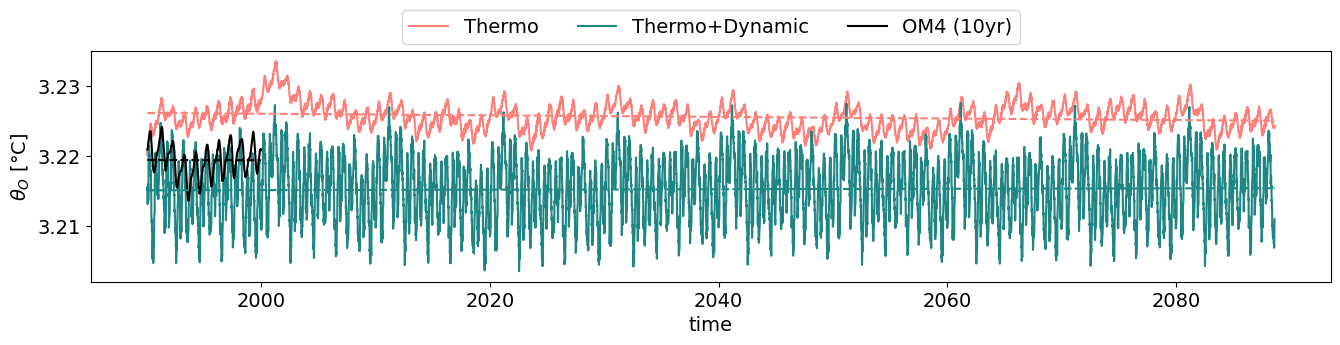

In [11]:
import matplotlib.pyplot as plt
import numpy as np

Days_to_Eq = 0

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(16, 3))  # Adjusted height

# Compute temperature prediction time series for another dataset
temp_pred_temp = ds_prediction_temp['thetao'][Days_to_Eq:].weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).mean(['x', 'y', 'lev']).compute()     
temp_pred_temp = temp_pred_temp.rename(r'$\theta_O$')
temp_pred_temp = temp_pred_temp.assign_attrs(units='°C')

# Plot additional temperature predictions
temp_pred_temp.plot(ax=ax, label=label_temp, color=color_2)

# Compute temperature prediction time series
temp_pred = ds_prediction_all['thetao'][Days_to_Eq:].weighted(ds_prediction_temp['areacello']*ds_prediction_temp['dz']).mean(['x', 'y', 'lev']).compute()     
temp_pred = temp_pred.rename(r'$\theta_O$')
temp_pred = temp_pred.assign_attrs(units='°C')

# Plot temperature predictions
temp_pred.plot(ax=ax, label=label_all, color=color_1)

# Compute temperature prediction time series
ground = ds_groundtruth['thetao'][Days_to_Eq:].weighted(ds_groundtruth['areacello']*ds_groundtruth['dz']).mean(['x', 'y', 'lev']).compute()     
ground = ground.rename(r'$\theta_O$')
ground = ground.assign_attrs(units='°C')

# Plot temperature predictions
ground.plot(ax=ax, label='OM4 (10yr)', color='k')

# Add legend and title
# ax.legend()
# ax.set_title("Temperature Timeseries")

# Calculate and plot linear trends for both datasets
coeffs_temp_pred_trend = np.polyfit(np.arange(temp_pred[:].size), temp_pred[:], 1)
ax.plot(temp_pred[:].time.data, np.arange(temp_pred[:].size) * coeffs_temp_pred_trend[0] + coeffs_temp_pred_trend[1], color=color_1, ls='--')

coeffs_temp_pred_trend_temp = np.polyfit(np.arange(temp_pred_temp[:].size), temp_pred_temp[:], 1)
ax.plot(temp_pred_temp[:].time.data, np.arange(temp_pred_temp[:].size) * coeffs_temp_pred_trend_temp[0] + coeffs_temp_pred_trend_temp[1], color=color_2, ls='--')

coeffs_ground = np.polyfit(np.arange(ground[:].size), ground[:], 1)
ax.plot(ground[:].time.data, np.arange(ground[:].size) * coeffs_ground[0] + coeffs_ground[1], color='k', ls='--')

# ax.legend(loc='upper right', ncol=3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.22), ncol=3)
plt.xticks(rotation=0, ha='center')

# Print trend coefficients
print(coeffs_temp_pred_trend[0] * 73)
print(coeffs_temp_pred_trend_temp[0] * 73)
print(coeffs_ground[0] * 73)

# Save figure
plt.savefig("../Figures/Temperature_Long" + suffix + ".png", bbox_inches='tight', dpi=600)
# plt.show()

In [12]:
print(ground.mean().compute())
print(temp_pred.mean().compute())
print(temp_pred_temp.mean().compute())

<xarray.DataArray '$\\theta_O$' ()>
array(3.21945731)
<xarray.DataArray '$\\theta_O$' ()>
array(3.2152956)
<xarray.DataArray '$\\theta_O$' ()>
array(3.22563876)


In [13]:
print(ground.std().compute())
print(temp_pred.std().compute())
print(temp_pred_temp.std().compute())

<xarray.DataArray '$\\theta_O$' ()>
array(0.00226657)
<xarray.DataArray '$\\theta_O$' ()>
array(0.00470061)
<xarray.DataArray '$\\theta_O$' ()>
array(0.00184142)


In [14]:
climatology = ground.groupby('time.dayofyear').mean('time').compute()
day_of_year = ground['time'].dt.dayofyear
ground_deas = (ground - climatology.sel(dayofyear=day_of_year)).compute()

climatology = temp_pred.groupby('time.dayofyear').mean('time').compute()
day_of_year = temp_pred['time'].dt.dayofyear
temp_pred_deas = (temp_pred - climatology.sel(dayofyear=day_of_year)).compute()

climatology = temp_pred_temp.groupby('time.dayofyear').mean('time').compute()
day_of_year = temp_pred_temp['time'].dt.dayofyear
temp_pred_temp_deas = (temp_pred_temp - climatology.sel(dayofyear=day_of_year)).compute()

In [15]:
print(ground_deas.std().compute())
print(temp_pred_deas.std().compute())
print(temp_pred_temp_deas.std().compute())

<xarray.DataArray '$\\theta_O$' ()>
array(0.00080573)
<xarray.DataArray '$\\theta_O$' ()>
array(0.00227099)
<xarray.DataArray '$\\theta_O$' ()>
array(0.00153886)


In [8]:
%matplotlib inline

In [10]:
from xarrayutils.plotting import linear_piecewise_scale
import matplotlib.pyplot as plt
import numpy as np
import cmocean as cm

plt.clf()
plt.rcParams.update({'font.size': 14})
# Define colormap
new_cmap = cm.cm.thermal 
new_cmap.set_bad('grey', .6)

# Number of rows and columns in the figure
num_basins = 1
num_models = 3
# Create figure with appropriate layout
fig, ax = plt.subplots(num_basins, num_models, figsize=(16, 3), 
                       gridspec_kw={'width_ratios': [1]*num_models, 
                                    'height_ratios': [1]*num_basins, 
                                    'wspace': 0.02, 'hspace': 0.5})
ax = np.array(ax)  # Ensure ax is an array for easy indexing

# Set common color range for the colorbar
vmin, vmax = 0, 30  # Adjust vmin/vmax based on expected temperature range, if known

# Plot for OM4
da_temp = ds_groundtruth['thetao']
section_mask = np.isnan(da_temp).all('x').isel(time=0)
da_temp_int_x = da_temp.weighted(ds_prediction_temp['areacello']).mean('x').mean('time')
temp_pred = da_temp_int_x.where(~section_mask)
temp_pred = temp_pred.rename(r'$\theta_O$').assign_attrs(units=r'\degree C')
temp_pred['y'] = temp_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
temp_pred['lev'] = temp_pred.lev.assign_attrs(long_name='depth', units='m')

om4_temp_profile = temp_pred
im = temp_pred.plot(ax=ax[0], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[0].invert_yaxis()
ax[0].set_title("OM4 (10yr)", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[0])
ax[0].axhline(1000, color='0.5', ls='--')
ax[0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

# Plot for "Thermo" data
da_temp = ds_prediction_temp['thetao']
section_mask = np.isnan(da_temp).all('x').isel(time=0)
da_temp_int_x = da_temp.weighted(ds_prediction_temp['areacello']).mean('x').mean('time')
temp_pred = da_temp_int_x.where(~section_mask)
temp_pred = temp_pred.rename(r'$\theta_O$').assign_attrs(units=r'\degree C')
temp_pred['y'] = temp_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
temp_pred['lev'] = temp_pred.lev.assign_attrs(long_name='depth', units='m')

thermo_temp_profile = temp_pred
im = temp_pred.plot(ax=ax[1], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[1].invert_yaxis()
ax[1].set_title("Thermo", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[1])
ax[1].axhline(1000, color='0.5', ls='--')
# ax[1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
ax[1].set_yticks([])
ax[1].set_ylabel("")

# Plot for "Thermo+Dynamic" data
da_temp = ds_prediction_all['thetao']
section_mask = np.isnan(da_temp).all('x').isel(time=0)
da_temp_int_x = da_temp.weighted(ds_prediction_temp['areacello']).mean('x').mean('time')
temp_pred = da_temp_int_x.where(~section_mask)
temp_pred = temp_pred.rename(r'$\theta_O$').assign_attrs(units=r'\degree C')
temp_pred['y'] = temp_pred.y.assign_attrs(long_name='latitude', units=r'$\degree$')
temp_pred['lev'] = temp_pred.lev.assign_attrs(long_name='depth', units='m')

thermodynamic_temp_profile = temp_pred
im = temp_pred.plot(ax=ax[2], cmap=new_cmap, vmin=vmin, vmax=vmax, add_colorbar=False)
ax[2].invert_yaxis()
ax[2].set_title("Thermo+Dynamic", fontsize=14)
linear_piecewise_scale(1000, 5, ax=ax[2])
ax[2].axhline(1000, color='0.5', ls='--')
# ax[2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])
ax[2].set_yticks([])
ax[2].set_ylabel("")

# Add shared colorbar for each row
cbar = fig.colorbar(im, ax=ax[:], orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label(r"$\theta_O$ [$\degree C$]")

# Save the figure

plt.savefig("../Figures/Temperature_Global_Profile_Long", bbox_inches='tight', dpi=600)
plt.close()

<Figure size 640x480 with 0 Axes>

In [ ]:
##### Diff profile and mean corr in profile.py in notebooks/

### ENSO

In [8]:
clim = ds_groundtruth['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()

In [10]:
clim_pred = ds_prediction_all['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()
clim_pred_temp = ds_prediction_temp['thetao'].sel(lev = slice(0,500)).groupby('time.dayofyear').mean().compute()

In [11]:
def NinoIndexComputeClim(T,area,dt = 5, window = 150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x = slice(190,240), y = slice(-5,5))
    area = area.sel(x = slice(190,240), y = slice(-5,5)).load()
    clim = T_clim.groupby('time.dayofyear').mean('time').compute()
    window = int(window/dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(Timestamp(t).dayofyear)
        T_clim[i] = (T[i]-clim.sel(dayofyear=day)).data        

    T_clim = T_clim.rolling(time = window).mean()
    # T_clim = (T_clim*area).sum(["x","y"])/area.sum(["x","y"])
    T_clim = T_clim.weighted(area).mean(["x", "y"])

    return T_clim[window:]

In [12]:
nino_compute_clim = NinoIndexComputeClim(ds_groundtruth['thetao'][:,0],ds_groundtruth['areacello'])
nino_compute_clim = nino_compute_clim.rename('Nino 3.4')
nino_compute_clim = nino_compute_clim.assign_attrs(units = r'$\degree C$')

In [13]:
nino_pred_compute_clim = NinoIndexComputeClim(ds_prediction_all['thetao'][:,0],ds_prediction_all['areacello'])
nino_pred_compute_clim_temp = NinoIndexComputeClim(ds_prediction_temp['thetao'][:,0],ds_prediction_all['areacello'])

nino_pred_compute_clim = nino_pred_compute_clim.rename('Nino 3.4')
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units = r'$\degree C$')

nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.rename('Nino 3.4')
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.assign_attrs(units = r'$\degree C$')

In [14]:
# import numpy as np
# day_max = int((np.argwhere(nino_pred_compute_clim_temp.values == np.nanmax(nino_pred_compute_clim_temp.values[-3000:])) + 30).squeeze())
# day_min = int((np.argwhere(nino_pred_compute_clim_temp.values == np.nanmin(nino_pred_compute_clim_temp.values[-3000:])) + 30).squeeze())

In [15]:
import numpy as np
day_max = int((np.argwhere(nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values[-3000:])) + 30).squeeze())
day_min = int((np.argwhere(nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values[-3000:])) + 30).squeeze())

In [16]:

# fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_true','nina_true'],['nino_pred','nina_pred'],['colorbar','colorbar']],figsize = (10,8),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.6,.5,.5,.05], 'wspace': 0.25,'hspace':.5})

# nino_pred_compute_clim.plot(label = label_all, c = color_1,ax = axs['time series'])
# nino_pred_compute_clim_temp.plot(label = label_temp, c = color_2,ax = axs['time series'])

# nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = color_1,ax = axs['time series'])
# nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = color_1,ax = axs['time series'])

# axs['time series'].set_title('')
# axs['time series'].set_xlabel('')
# axs['time series'].legend()

# axs['time series'].set_xticks(ax.get_xticks())
# axs['time series'].set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
# # axs['time series'].set_xticklabels(axs['time series'].get_xticklabels(),rotation=0)
# # axs['time series'].set_title('Nino 3.4 Index')

# day_start = day_max
# window = 3

# time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
# times = ds_prediction_temp['time'][day_start:day_start+window].data
# days_of_year = [Timestamp(i).dayofyear for i in times]
# true_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
# true_clim_to_remove['time'] = times
# pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
# pred_clim_to_remove['time'] = times

# tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
# tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
# tropics_profile = tropics_profile.rename('Anomaly')
# tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
# tropics_profile = tropics_profile.assign_attrs(units = r'$\degree C$')
# tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r'$\degree C$')
# tropics_profile["x"]= tropics_profile.x.assign_attrs(units = r'$\degree C$')
# tropics_profile['lev'] = tropics_profile.lev.assign_attrs(long_name='depth', units='m')
# tropics_profile_pred["x"] = tropics_profile_pred.x.assign_attrs(units = r'$\degree C$')
# tropics_profile_pred['lev'] = tropics_profile_pred.lev.assign_attrs(long_name='depth', units='m')

# tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
# axs['nino_true'].set_title('Nino Conditions ' + label_all)
# axs['nino_true'].set_xlabel('')
# axs['nino_true'].invert_yaxis()
# tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
# axs['nino_pred'].set_title('Nino Conditions ' + label_temp)
# # axs['nino_pred'].set_xlabel('')
# axs['nino_pred'].invert_yaxis()


# axs['time series'].legend()

# day_start = day_min
# window = 3

# time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
# times = ds_prediction_temp['time'][day_start:day_start+window].data
# days_of_year = [Timestamp(i).dayofyear for i in times]
# pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
# pred_clim_to_remove['time'] = times
# true_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
# true_clim_to_remove['time'] = times

# tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
# tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
# tropics_profile = tropics_profile.rename('Anomaly')
# tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
# tropics_profile = tropics_profile.assign_attrs(units = r'$\degree C$')
# tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r'$\degree C$')

# tropics_profile["x"]= tropics_profile.x.assign_attrs(units = r'$\degree C$')
# tropics_profile['lev'] = tropics_profile.lev.assign_attrs(long_name='depth', units='m')
# tropics_profile_pred["x"] = tropics_profile_pred.x.assign_attrs(units = r'$\degree C$')
# tropics_profile_pred['lev'] = tropics_profile_pred.lev.assign_attrs(long_name='depth', units='m')

# tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
# axs['nina_true'].set_title('Nina Conditions '+label_all)
# axs['nina_true'].set_xlabel('')
# # axs['nina_true'].set_ylabel('')
# axs['nina_true'].invert_yaxis()
# tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
#                         "orientation": "horizontal",
#                         "shrink": 0.3,
#                         "extend": "both",
#                     })
# axs['nina_pred'].set_title('Nina Conditions '+label_temp)
# # axs['nina_pred'].set_ylabel('')
# axs['nina_pred'].invert_yaxis()

# plt.savefig("../Figures/Nino_Figure_Long"+suffix+"_no_map.png", bbox_inches='tight', dpi =600)
# # plt.show()

In [17]:
from matplotlib import text
ticks = [ 10957., 18262., 25567., 32872., 40177.]
ticklabels = [
 text.Text(10957.0, 0, '2000'),
 text.Text(18262.0, 0, '2020'),
 text.Text(25567.0, 0, '2040'),
 text.Text(32872.0, 0, '2060'),
 text.Text(40177.0, 0, '2080')]

<xarray.DataArray 'Nino 3.4' (time: 7170)>
array([-0.13932117, -0.12300981, -0.10622405, ..., -0.16736362,
       -0.25021032, -0.32717573])
Coordinates:
    dz       int64 5
    lev      float64 2.5
  * time     (time) datetime64[ns] 1990-06-17T12:00:00 ... 2088-08-06T12:00:00
Attributes:
    units:    $\degree C$

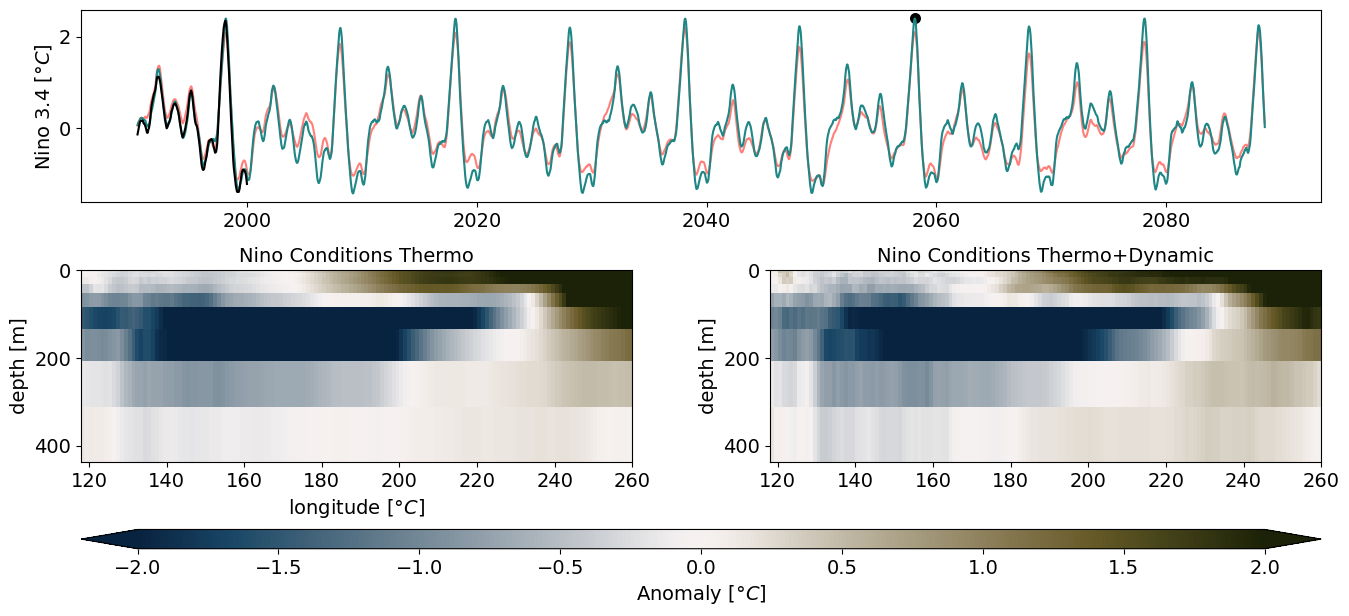

In [22]:
plt.rcParams.update({'font.size': 14})
fig,axs = plt.subplot_mosaic([['time series','time series'],['nino_pred','nino_true'],['colorbar','colorbar']],figsize = (16,7),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5,.05], 'wspace': 0.25,'hspace':.5})

nino_pred_compute_clim_temp.plot(label = label_temp, c = color_2,ax = axs['time series'])
nino_pred_compute_clim.plot(label = label_all, c = color_1,ax = axs['time series'])
nino_compute_clim.sel(time=slice("1990-01-01", "1999-12-31")).plot(label = 'OM4 (10yr)', c = 'k', ax = axs['time series'])

nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])
# nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].set_xlabel('')
# axs['time series'].legend(ncol=3)

axs['time series'].set_xticks(ticks)
axs['time series'].set_xticklabels(ticklabels, rotation=0, ha='center')
# axs['time series'].set_xticklabels(axs['time series'].get_xticklabels(),rotation=0)
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [Timestamp(i).dayofyear for i in times]
true_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times
pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times

tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r'$\degree C$')
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r'$\degree C$')
tropics_profile["x"]= tropics_profile.x.assign_attrs(units = r'$\degree C$')
tropics_profile['lev'] = tropics_profile.lev.assign_attrs(long_name='depth', units='m')
tropics_profile_pred["x"] = tropics_profile_pred.x.assign_attrs(units = r'$\degree C$')
tropics_profile_pred['lev'] = tropics_profile_pred.lev.assign_attrs(long_name='depth', units='m')

tropics_profile.plot.pcolormesh(ax = axs['nino_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nino_true'].set_title('Nino Conditions ' + label_all, fontsize=14)
axs['nino_true'].set_xlabel('')
axs['nino_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nino_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
                        "orientation": "horizontal",
                        "shrink": 0.3,
                        "extend": "both",
                    })
axs['nino_pred'].set_title('Nino Conditions ' + label_temp, fontsize=14)
# axs['nino_pred'].set_xlabel('')
axs['nino_pred'].invert_yaxis()

plt.savefig("../Figures/NinoOnly_Figure_Long"+suffix+"_no_map.png", bbox_inches='tight', dpi =600)
# plt.show()

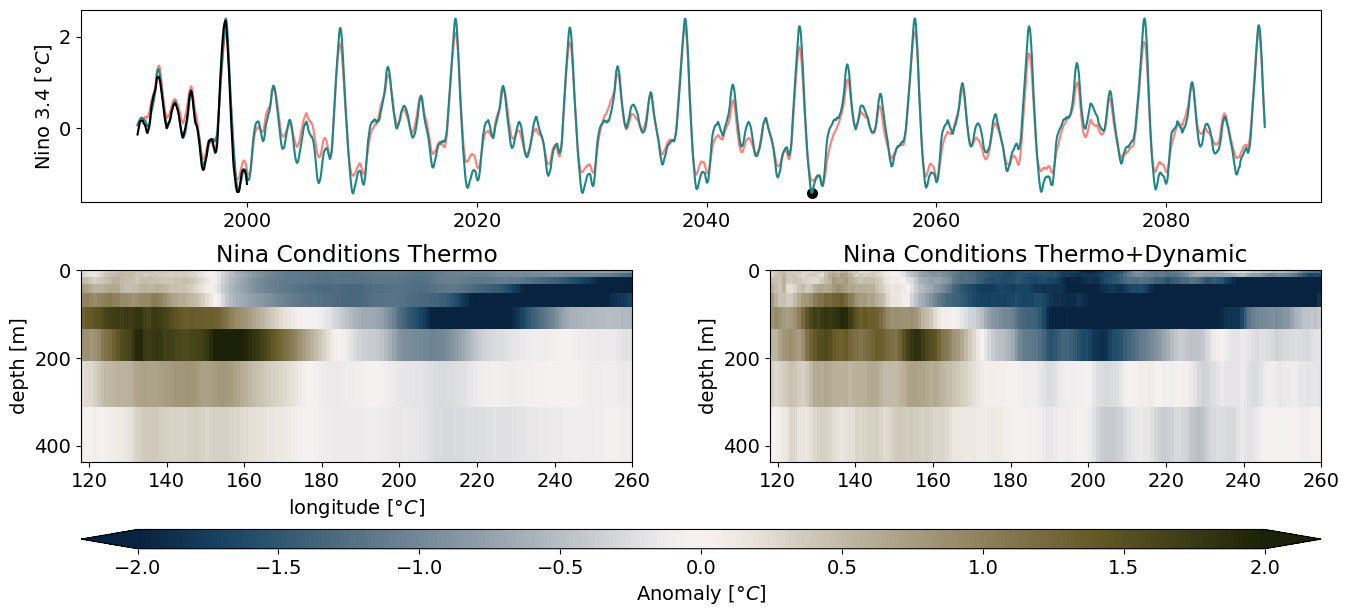

In [24]:
plt.rcParams.update({'font.size': 14})
fig,axs = plt.subplot_mosaic([['time series','time series'],['nina_pred','nina_true'],['colorbar','colorbar']],figsize = (16,7),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [.5,.5,.05], 'wspace': 0.25,'hspace':.5})

nino_pred_compute_clim_temp.plot(label = label_temp, c = color_2,ax = axs['time series'])
nino_pred_compute_clim.plot(label = label_all, c = color_1,ax = axs['time series'])
nino_compute_clim.sel(time=slice("1990-01-01", "1999-12-31")).plot(label = 'OM4 (10yr)', c = 'k', ax = axs['time series'])

# nino_pred_compute_clim.isel(time = slice(day_max-30,day_max-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])
nino_pred_compute_clim.isel(time = slice(day_min-30,day_min-30+1)).drop_vars(['dz','lev']).plot.scatter(s = 80, c = 'k',ax = axs['time series'])

axs['time series'].set_title('')
axs['time series'].set_xlabel('')
# axs['time series'].legend(ncol=3)

axs['time series'].set_xticks(ticks)
axs['time series'].set_xticklabels(ticklabels, rotation=0, ha='center')
# axs['time series'].set_xticklabels(axs['time series'].get_xticklabels(),rotation=0)
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_min
window = 3

time_slice = slice(ds_prediction_temp['time'][day_start],ds_prediction_temp['time'][day_start+window])
times = ds_prediction_temp['time'][day_start:day_start+window].data
days_of_year = [Timestamp(i).dayofyear for i in times]
pred_clim_to_remove = clim_pred_temp.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
pred_clim_to_remove['time'] = times
true_clim_to_remove = clim_pred.sel(dayofyear = days_of_year).rename({'dayofyear': 'time'})
true_clim_to_remove['time'] = times

tropics_profile = (ds_prediction_all['thetao'].sel(time = time_slice,x = slice(118,260), y = slice(-5,5),lev = slice(0,500),)-true_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile_pred = (ds_prediction_temp['thetao'][day_start:day_start+window].sel(lev = slice(0,500),x = slice(118,260), y = slice(-5,5))-pred_clim_to_remove.sel(x = slice(118,260), y = slice(-5,5))).mean(['time','y'])
tropics_profile = tropics_profile.rename('Anomaly')
tropics_profile_pred = tropics_profile_pred.rename('Anomaly')
tropics_profile = tropics_profile.assign_attrs(units = r'$\degree C$')
tropics_profile_pred = tropics_profile_pred.assign_attrs(units = r'$\degree C$')

tropics_profile["x"]= tropics_profile.x.assign_attrs(units = r'$\degree C$')
tropics_profile['lev'] = tropics_profile.lev.assign_attrs(long_name='depth', units='m')
tropics_profile_pred["x"] = tropics_profile_pred.x.assign_attrs(units = r'$\degree C$')
tropics_profile_pred['lev'] = tropics_profile_pred.lev.assign_attrs(long_name='depth', units='m')

tropics_profile.plot.pcolormesh(ax = axs['nina_true'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,add_colorbar = False)
axs['nina_true'].set_title('Nina Conditions '+label_all)
axs['nina_true'].set_xlabel('')
# axs['nina_true'].set_ylabel('')
axs['nina_true'].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(ax = axs['nina_pred'],y = 'lev',cmap = cm.cm.diff,vmin = -2,vmax = 2,cbar_ax=axs['colorbar'],cbar_kwargs={
                        "orientation": "horizontal",
                        "shrink": 0.3,
                        "extend": "both",
                    })
axs['nina_pred'].set_title('Nina Conditions '+label_temp)
# axs['nina_pred'].set_ylabel('')
axs['nina_pred'].invert_yaxis()
plt.savefig("../Figures/NinaOnly_Figure_Long"+suffix+"_no_map.png", bbox_inches='tight', dpi =600)
# plt.show()

---


In [ ]:
# # Compute Basin Heat Content Time Series
# Days_to_Eq = 1000

# basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

# mask = merged_mask(basins,ds_prediction_all.drop_vars(['lat','lon']))

# atlantic_mask = xr.where(np.logical_or(mask == 0,mask == 1),1.0,np.nan)
# pacific_mask = xr.where(np.logical_or(mask == 2,mask == 3),1.0,np.nan)
# southern_ocean_mask = xr.where(mask == 7,1.0,np.nan)
# indian_ocean_mask = xr.where(mask == 5,1.0,np.nan)

# masks = atlantic_mask.to_dataset(name='Atlantic')
# masks['Pacific']  = pacific_mask
# masks['Southern'] = southern_ocean_mask
# masks['Indian'] = indian_ocean_mask

# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(2,2,figsize=(10,5),gridspec_kw={'width_ratios': [1,1], 'height_ratios': [1,1], 'wspace': 0.25,'hspace':.5})
# ax_flat = ax.flatten()

# for i, var in enumerate(list(masks.keys())):
#     OHC_pred = ((ds_prediction_all['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
#     OHC_pred.plot(ax = ax_flat[i], label = label_all, c = color_1)

#     OHC_pred_temp = ((ds_prediction_temp['thetao']*c_p*rho_0*masks[var])*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev'])    
#     OHC_pred_temp.plot(ax = ax_flat[i], label = label_temp, c = color_2)
    
#     ax_flat[i].legend()
#     ax_flat[i].set_title("Heat Content " + var + " Ocean")
#     coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[Days_to_Eq:].size), OHC_pred[Days_to_Eq:], 1)
#     ax_flat[i].plot(OHC_pred[Days_to_Eq:].time.data, np.arange(OHC_pred[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
    
#     coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[Days_to_Eq:].size), OHC_pred_temp[Days_to_Eq:], 1)
#     ax_flat[i].plot(OHC_pred_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')

# plt.savefig(os.path.join(output_path, "Basins_OHC_Salinity_Long.png"), bbox_inches='tight',dpi =600)


/home/sd5313/.local/lib/python3.10/site-packages/regionmask/core/mask.py:169: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


In [ ]:
# # Compute Basin Heat Content Time Series

# Days_to_Eq = 0
# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

# OHC_pred_upper = ((ds_prediction_all['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
# OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 700m')
# OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

# OHC_pred_upper.plot(ax = ax[0], label = label_all, c = color_1)

# OHC_pred_upper_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() 
# OHC_pred_upper_temp = OHC_pred_upper_temp.rename('OHC Upper 700m')
# OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units = 'J')

# OHC_pred_upper_temp.plot(ax = ax[0], label = label_temp, c = color_2)

# # ax[0].legend()
# ax[0].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper[Days_to_Eq:].time.data, np.arange(OHC_pred_upper[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_upper_temp[Days_to_Eq:].size), OHC_pred_upper_temp[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
# ax[0].legend()

# upper_trend = coeffs_OHC_pred_trend[0]*73
# upper_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


# OHC_pred_mid = ((ds_prediction_all['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_mid = OHC_pred_mid.rename('OHC  0.7-2km')
# OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

# OHC_pred_mid.plot(ax = ax[1], label = label_all, c = color_1)

# OHC_pred_mid_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(700,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
# OHC_pred_mid_temp = OHC_pred_mid_temp.rename('OHC  0.7-2km')
# OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units = 'J')

# OHC_pred_mid_temp.plot(ax = ax[1], label = label_temp, c = color_2)

# ax[1].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid[Days_to_Eq:].time.data, np.arange(OHC_pred_mid[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)

# mid_trend = coeffs_OHC_pred_trend[0]*73
# mid_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


# OHC_pred_deep = ((ds_prediction_all['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_deep = OHC_pred_deep.rename('OHC 2km to bottom')
# OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

# OHC_pred_deep.plot(ax = ax[2], label = label_all, c = color_1)

# OHC_pred_deep_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_deep_temp = OHC_pred_deep_temp.rename('OHC 2km to bottom')
# OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units = 'J')

# OHC_pred_deep_temp.plot(ax = ax[2], label = label_temp, c = color_2)

# # ax[0].legend()
# ax[2].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep[Days_to_Eq:].time.data, np.arange(OHC_pred_deep[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)

# deep_trend = coeffs_OHC_pred_trend[0]*73
# deep_trend_temp = coeffs_OHC_pred_trend_temp[0]*73

# total_trend = upper_trend + mid_trend + deep_trend
# total_trend_temp = upper_trend_temp + mid_trend_temp + deep_trend_temp

# print(f'OHC portion of upper trend: {upper_trend/total_trend:.2f}')
# print(f'OHC portion of mid trend: {mid_trend/total_trend:.2f}')
# print(f'OHC portion of deep trend: {deep_trend/total_trend:.2f}')
# print(f'OHC portion of upper trend temp: {upper_trend_temp/total_trend_temp:.2f}')
# print(f'OHC portion of mid trend temp: {mid_trend_temp/total_trend_temp:.2f}')
# print(f'OHC portion of deep trend temp: {deep_trend_temp/total_trend_temp:.2f}')

# plt.savefig(os.path.join(output_path, "Depth_OHC_Long_"+suffix+".png"), bbox_inches='tight',dpi =600)
# # plt.show()

In [ ]:
# # Compute Basin Heat Content Time Series

# Days_to_Eq = 0
# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(3,1,figsize=(10,7.5),gridspec_kw={'wspace': 0.25,'hspace':.5})

# OHC_pred_upper = ((ds_prediction_all['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
# OHC_pred_upper = OHC_pred_upper.rename('OHC Upper 700m')
# OHC_pred_upper = OHC_pred_upper.assign_attrs(units = 'J')

# OHC_pred_upper.plot(ax = ax[0], label = label_all, c = color_1)

# OHC_pred_upper_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,700))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute() 
# OHC_pred_upper_temp = OHC_pred_upper_temp.rename('OHC Upper 700m')
# OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units = 'J')

# OHC_pred_upper_temp.plot(ax = ax[0], label = label_temp, c = color_2)

# # ax[0].legend()
# ax[0].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper[Days_to_Eq:].time.data, np.arange(OHC_pred_upper[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_upper_temp[Days_to_Eq:].size), OHC_pred_upper_temp[Days_to_Eq:], 1)
# ax[0].plot(OHC_pred_upper_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_upper_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
# ax[0].legend()

# upper_trend = coeffs_OHC_pred_trend[0]*73
# upper_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


# OHC_pred_mid = ((ds_prediction_all['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_mid = OHC_pred_mid.rename('OHC Upper 2000m')
# OHC_pred_mid = OHC_pred_mid.assign_attrs(units = 'J')

# OHC_pred_mid.plot(ax = ax[1], label = label_all, c = color_1)

# OHC_pred_mid_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(0,2000))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()    
# OHC_pred_mid_temp = OHC_pred_mid_temp.rename('OHC Upper 2000m')
# OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units = 'J')

# OHC_pred_mid_temp.plot(ax = ax[1], label = label_temp, c = color_2)

# ax[1].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid[Days_to_Eq:].time.data, np.arange(OHC_pred_mid[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1)
# ax[1].plot(OHC_pred_mid_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_mid_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)

# mid_trend = coeffs_OHC_pred_trend[0]*73
# mid_trend_temp = coeffs_OHC_pred_trend_temp[0]*73


# OHC_pred_deep = ((ds_prediction_all['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_deep = OHC_pred_deep.rename('OHC 2km to bottom')
# OHC_pred_deep = OHC_pred_deep.assign_attrs(units = 'J')

# OHC_pred_deep.plot(ax = ax[2], label = label_all, c = color_1)

# OHC_pred_deep_temp = ((ds_prediction_temp['thetao'].sel(lev = slice(2000,None))*c_p*rho_0)*ds_prediction_all['areacello']*ds_prediction_all['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_deep_temp = OHC_pred_deep_temp.rename('OHC 2km to bottom')
# OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units = 'J')

# OHC_pred_deep_temp.plot(ax = ax[2], label = label_temp, c = color_2)

# # ax[0].legend()
# ax[2].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep[Days_to_Eq:].time.data, np.arange(OHC_pred_deep[Days_to_Eq:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1)
# ax[2].plot(OHC_pred_deep_temp[Days_to_Eq:].time.data, np.arange(OHC_pred_deep_temp[Days_to_Eq:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)

# deep_trend = coeffs_OHC_pred_trend[0]*73
# deep_trend_temp = coeffs_OHC_pred_trend_temp[0]*73

# total_trend = upper_trend + mid_trend + deep_trend
# total_trend_temp = upper_trend_temp + mid_trend_temp + deep_trend_temp

# print(f'OHC portion of upper trend: {upper_trend/total_trend:.2f}')
# print(f'OHC portion of mid trend: {mid_trend/total_trend:.2f}')
# print(f'OHC portion of deep trend: {deep_trend/total_trend:.2f}')
# print(f'OHC portion of upper trend temp: {upper_trend_temp/total_trend_temp:.2f}')
# print(f'OHC portion of mid trend temp: {mid_trend_temp/total_trend_temp:.2f}')
# print(f'OHC portion of deep trend temp: {deep_trend_temp/total_trend_temp:.2f}')

# plt.savefig(os.path.join(output_path, "Depth_OHC_Long_"+suffix+".png"), bbox_inches='tight',dpi =600)
# # plt.show()

In [ ]:
# Days_to_Eq = 0

# c_p = 3850 #J/(kg C) 
# rho_0 = 1025 #kg/m^3

# fig, ax = plt.subplots(2,1,figsize=(10,5),gridspec_kw={'wspace': 0.25,'hspace':.5})

# OHC_pred = ((ds_prediction_all['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# OHC_pred = OHC_pred.rename('Ocean Heat Content')
# OHC_pred = OHC_pred.assign_attrs(units = 'J')

# OHC_pred.plot(ax = ax[0], label = label_all, c = color_1)

# OHC_pred_temp = ((ds_prediction_temp['thetao'][Days_to_Eq:]*c_p*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# OHC_pred_temp = OHC_pred_temp.rename('Ocean Heat Content')
# OHC_pred_temp = OHC_pred_temp.assign_attrs(units = 'J')

# OHC_pred_temp.plot(ax = ax[0], label = label_temp, c = color_2)

# # ax[0].legend()
# ax[0].set_title("Ocean Heat Content")
# coeffs_OHC_pred_trend= np.polyfit(np.arange(OHC_pred[:].size), OHC_pred[:], 1)
# ax[0].plot(OHC_pred[:].time.data, np.arange(OHC_pred[:].size)*coeffs_OHC_pred_trend[0] + coeffs_OHC_pred_trend[1],c = color_1, ls = '--')
# coeffs_OHC_pred_trend_temp= np.polyfit(np.arange(OHC_pred_temp[:].size), OHC_pred_temp[:], 1)
# ax[0].plot(OHC_pred_temp[:].time.data, np.arange(OHC_pred_temp[:].size)*coeffs_OHC_pred_trend_temp[0] + coeffs_OHC_pred_trend_temp[1],c = color_2, ls = '--')
# ax[0].legend(loc = 'lower right')

# salinity = ((ds_prediction_all['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# salinity = salinity.rename('Salinity')
# salinity = salinity.assign_attrs(units = 'g')

# salinity.plot(ax = ax[1], label = label_all, c = color_1)

# salinity_temp = ((ds_prediction_temp['so'][Days_to_Eq:]*rho_0)*ds_prediction_temp['areacello']*ds_prediction_temp['dz']).sum(['x','y','lev']).compute()     
# salinity_temp = salinity_temp.rename('Salinity')
# salinity_temp_temp = salinity_temp.assign_attrs(units = 'g')

# salinity_temp.plot(ax = ax[1], label = label_temp, c = color_2)

# # ax[1].legend()
# ax[1].set_title("Ocean Total Salinity")
# coeffs_salinity_trend= np.polyfit(np.arange(salinity[:].size), salinity[:], 1)
# ax[1].plot(salinity[:].time.data, np.arange(salinity[:].size)*coeffs_salinity_trend[0] + coeffs_salinity_trend[1],c = color_1, ls = '--')

# coeffs_salinity_trend_temp= np.polyfit(np.arange(salinity_temp[:].size), salinity_temp[:], 1)
# ax[1].plot(salinity_temp[:].time.data, np.arange(salinity_temp[:].size)*coeffs_salinity_trend_temp[0] + coeffs_salinity_trend_temp[1],c = color_2, ls = '--')

# print(coeffs_OHC_pred_trend[0]*73/1e21)

# print(coeffs_salinity_trend[0]*73/1e17)

# print(coeffs_OHC_pred_trend_temp[0]*73/1e21)

# print(coeffs_salinity_trend_temp[0]*73/1e17)
# plt.savefig(os.path.join(output_path, "OHC_Salinity_Long"+suffix+".png"), bbox_inches='tight',dpi =600)
# # plt.show()
